# MCMC Kernels on Challenging 2D Densities

We compare MCMC kernels on three targets:
1. **Neal's funnel** — varying curvature, strong correlation
2. **Gaussian mixture** — 5 well-separated modes, discrete multimodality
3. **Spiral** — three-turn Archimedean spiral, thin curved ridge

In [13]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

jax.config.update("jax_platform_name", "cpu")

from probjax.inference.mcmc import (
    hmc,
    nuts,
    dynamic_hmc,
    mala,
    gauss_rwmh,
    gaussian_imh,
    elliptical_slice,
    slice,
    latent_slice,
    mclmc,
    adjusted_mclmc,
    adjusted_mclmc_dynamic,
)
from probjax.inference import compose_adaptors
from probjax.inference.mcmc import (
    covariance_adaptor,
    slice_step_size_adaptor,
    step_size_adaptor,
    window_warmup,
)
from probjax.inference.mcmc_runner import MCMC

## Target densities

In [14]:
# --- Neal's funnel ---
def funnel_logdensity(z):
    x, v = z[0], z[1]
    return jax.scipy.stats.norm.logpdf(v, 0.0, 3.0) + \
           jax.scipy.stats.norm.logpdf(x, 0.0, jnp.exp(v / 2.0))

key = jax.random.PRNGKey(42)
v_ref = jax.random.normal(key, (100_000,)) * 3.0
key, subkey = jax.random.split(key)
x_ref = jax.random.normal(subkey, (100_000,)) * jnp.exp(v_ref / 2.0)


# --- Gaussian mixture ---
mixture_means = jnp.array([
    [10.0, 0.0], [0.0, 10.0], [-10.0, 0.0], [0.0, -10.0], [0.0, 0.0],
])
mixture_std = 0.7

def mixture_logdensity(z):
    logps = jax.vmap(
        lambda mu: jax.scipy.stats.norm.logpdf(z, mu, mixture_std).sum()
    )(mixture_means)
    return jax.scipy.special.logsumexp(logps) - jnp.log(len(mixture_means))

key = jax.random.PRNGKey(99)
comp = jax.random.choice(key, len(mixture_means), shape=(100_000,))
key, subkey = jax.random.split(key)
y_ref = mixture_means[comp] + jax.random.normal(subkey, (100_000, 2)) * mixture_std


# --- Spiral ---
# A thin three-turn Archimedean spiral approximated by a Gaussian mixture.
key = jax.random.PRNGKey(7)
t_spiral = jnp.linspace(0.0, 6 * jnp.pi, 150)
spiral_scale = 0.15
spiral_std = 0.15
spiral_means = spiral_scale * jnp.stack(
    [t_spiral * jnp.cos(t_spiral), t_spiral * jnp.sin(t_spiral)], axis=-1
)

def spiral_logdensity(z):
    logps = jax.vmap(
        lambda mu: jax.scipy.stats.norm.logpdf(z, mu, spiral_std).sum()
    )(spiral_means)
    return jax.scipy.special.logsumexp(logps) - jnp.log(len(spiral_means))

comp = jax.random.choice(key, len(spiral_means), shape=(100_000,))
key, subkey = jax.random.split(key)
s_ref = spiral_means[comp] + jax.random.normal(subkey, (100_000, 2)) * spiral_std

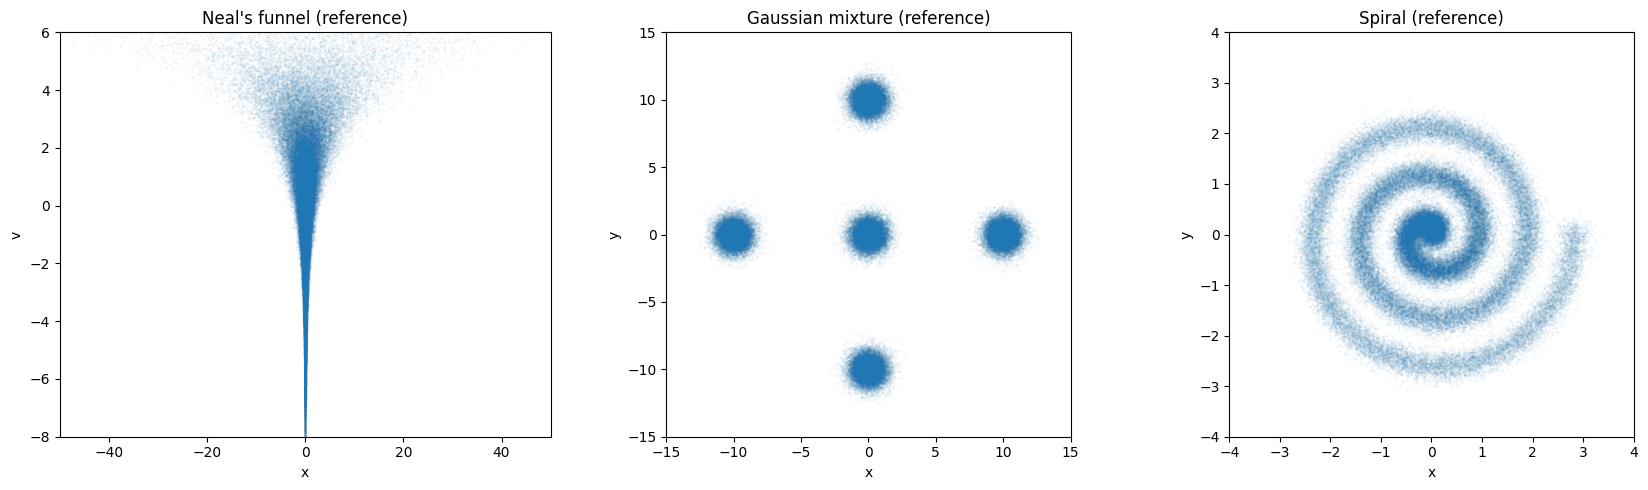

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

axes[0].scatter(x_ref, v_ref, s=0.1, alpha=0.1, rasterized=True)
axes[0].set_xlim(-50, 50); axes[0].set_ylim(-8, 6)
axes[0].set_xlabel("x"); axes[0].set_ylabel("v")
axes[0].set_title("Neal's funnel (reference)")

axes[1].scatter(y_ref[:, 0], y_ref[:, 1], s=0.1, alpha=0.1, rasterized=True)
axes[1].set_xlim(-15, 15); axes[1].set_ylim(-15, 15)
axes[1].set_aspect("equal")
axes[1].set_xlabel("x"); axes[1].set_ylabel("y")
axes[1].set_title("Gaussian mixture (reference)")

axes[2].scatter(s_ref[:, 0], s_ref[:, 1], s=0.1, alpha=0.1, rasterized=True)
axes[2].set_xlim(-4, 4); axes[2].set_ylim(-4, 4)
axes[2].set_aspect("equal")
axes[2].set_xlabel("x"); axes[2].set_ylabel("y")
axes[2].set_title("Spiral (reference)")

plt.tight_layout()
plt.show()

## Helper

In [16]:
def run_mcmc(kernel, init_z, key, num_samples=20_000, thin=10, init_kwargs=None, init_params_kwargs=None):
    state = kernel.init(key, init_z, **(init_kwargs or {}))
    params = kernel.init_params(state, **(init_params_kwargs or {}))
    result = MCMC(kernel).sample(key, state, num_samples, params=params, thin=thin)
    return result.samples


def plot_triplet(name, s_funnel, s_mixture, s_spiral):
    fig, axes = plt.subplots(1, 3, figsize=(17, 5))

    axes[0].scatter(s_funnel[:, 0], s_funnel[:, 1], s=0.5, alpha=0.4, rasterized=True)
    axes[0].set_xlim(-50, 50); axes[0].set_ylim(-8, 6)
    axes[0].set_xlabel("x"); axes[0].set_ylabel("v")
    axes[0].set_title(f"{name} — funnel")

    axes[1].scatter(s_mixture[:, 0], s_mixture[:, 1], s=0.5, alpha=0.4, rasterized=True)
    axes[1].set_xlim(-15, 15); axes[1].set_ylim(-15, 15)
    axes[1].set_aspect("equal")
    axes[1].set_xlabel("x"); axes[1].set_ylabel("y")
    axes[1].set_title(f"{name} — mixture")

    axes[2].scatter(s_spiral[:, 0], s_spiral[:, 1], s=0.5, alpha=0.4, rasterized=True)
    axes[2].set_xlim(-4, 4); axes[2].set_ylim(-4, 4)
    axes[2].set_aspect("equal")
    axes[2].set_xlabel("x"); axes[2].set_ylabel("y")
    axes[2].set_title(f"{name} — Spiral")

    plt.tight_layout()
    plt.show()

In [17]:
init_funnel = jnp.array([0.0, -1.0])
init_mixture = jnp.array([10.0, 0.0])
init_spiral = jnp.array([2.8, 0.0])
key = jax.random.PRNGKey(0)

## HMC

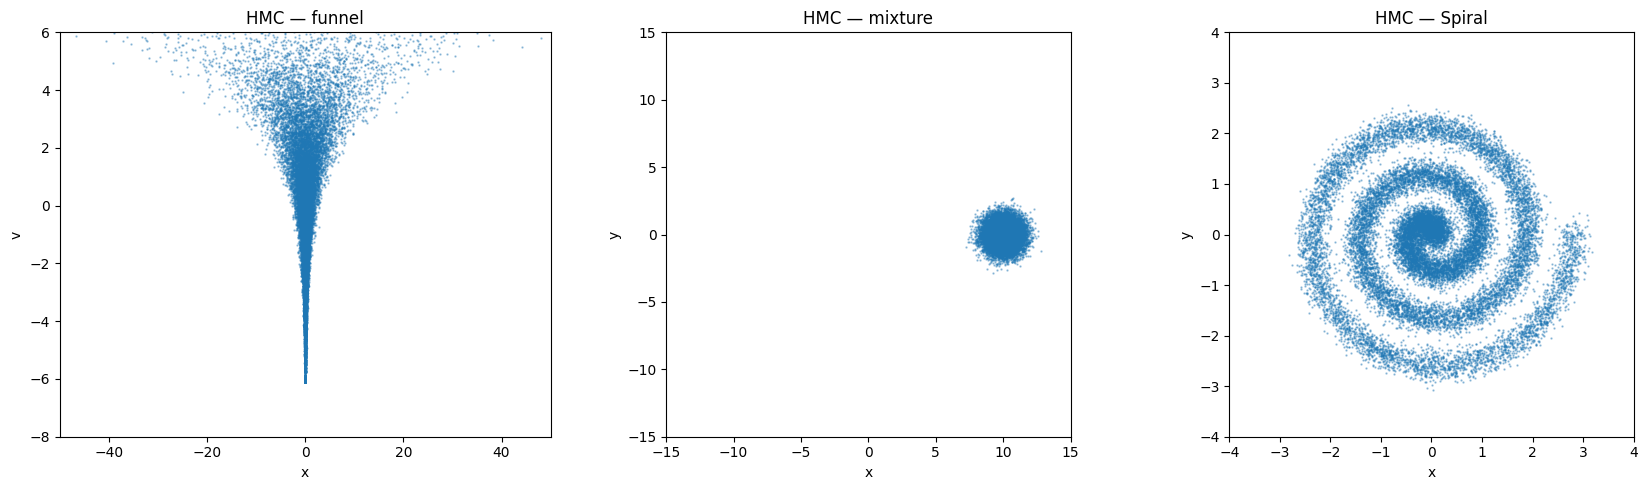

In [18]:
s_f = run_mcmc(hmc(funnel_logdensity, num_integration_steps=50), init_funnel, key, init_params_kwargs={"step_size": 0.05})
s_m = run_mcmc(hmc(mixture_logdensity, num_integration_steps=50), init_mixture, key, init_params_kwargs={"step_size": 0.05})
s_s = run_mcmc(hmc(spiral_logdensity, num_integration_steps=50), init_spiral, key, init_params_kwargs={"step_size": 0.05})
plot_triplet("HMC", s_f, s_m, s_s)

## NUTS

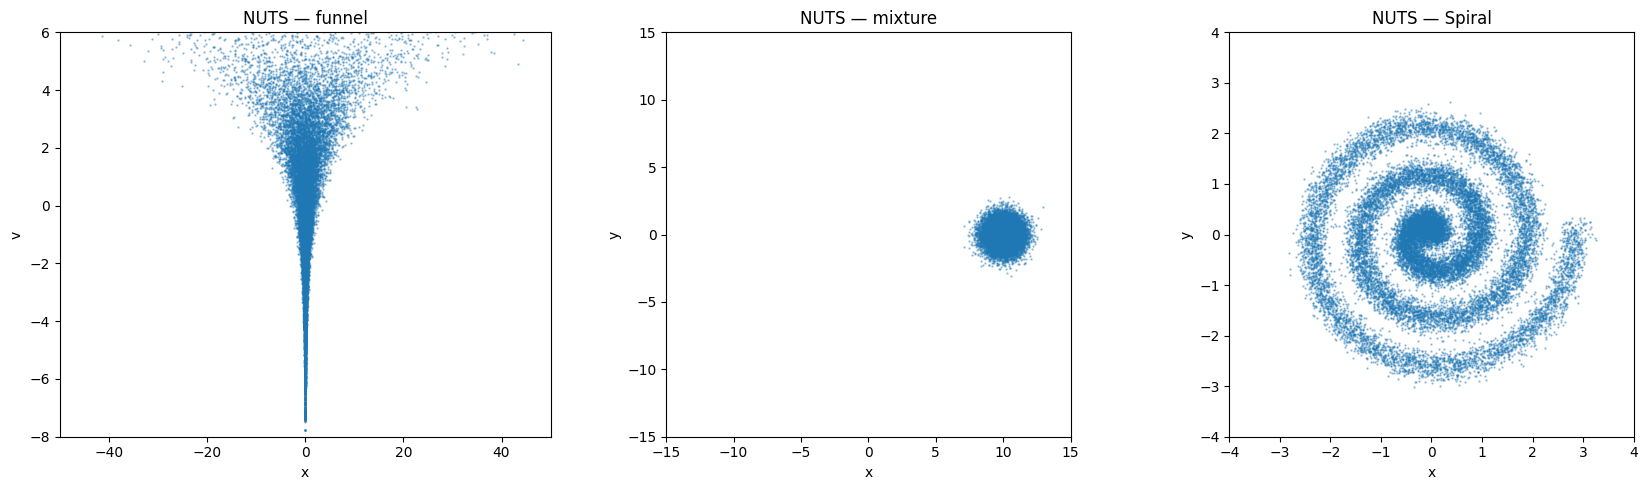

In [19]:
s_f = run_mcmc(nuts(funnel_logdensity, max_num_doublings=10), init_funnel, key, init_params_kwargs={"step_size": 0.05})
s_m = run_mcmc(nuts(mixture_logdensity, max_num_doublings=10), init_mixture, key, init_params_kwargs={"step_size": 0.05})
s_s = run_mcmc(nuts(spiral_logdensity, max_num_doublings=10), init_spiral, key, init_params_kwargs={"step_size": 0.05})
plot_triplet("NUTS", s_f, s_m, s_s)

## Dynamic HMC

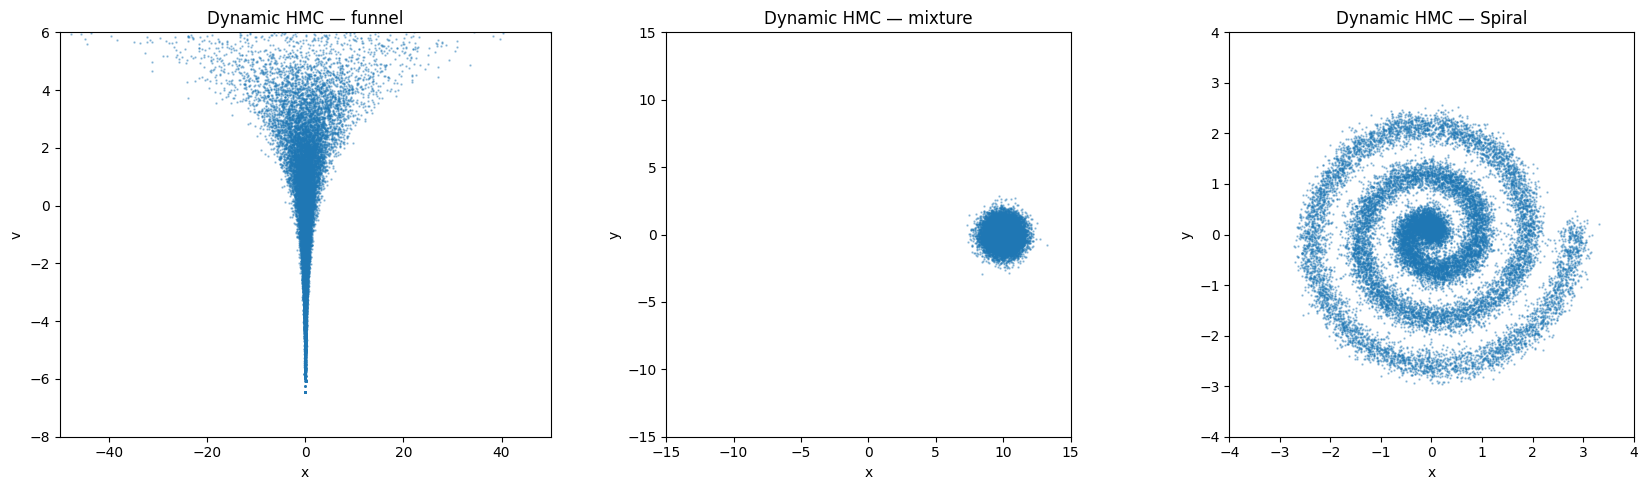

In [20]:
s_f = run_mcmc(dynamic_hmc(funnel_logdensity, average_integration_steps=50), init_funnel, key, init_params_kwargs={"step_size": 0.05})
s_m = run_mcmc(dynamic_hmc(mixture_logdensity, average_integration_steps=50), init_mixture, key, init_params_kwargs={"step_size": 0.05})
s_s = run_mcmc(dynamic_hmc(spiral_logdensity, average_integration_steps=50), init_spiral, key, init_params_kwargs={"step_size": 0.05})
plot_triplet("Dynamic HMC", s_f, s_m, s_s)

## MALA

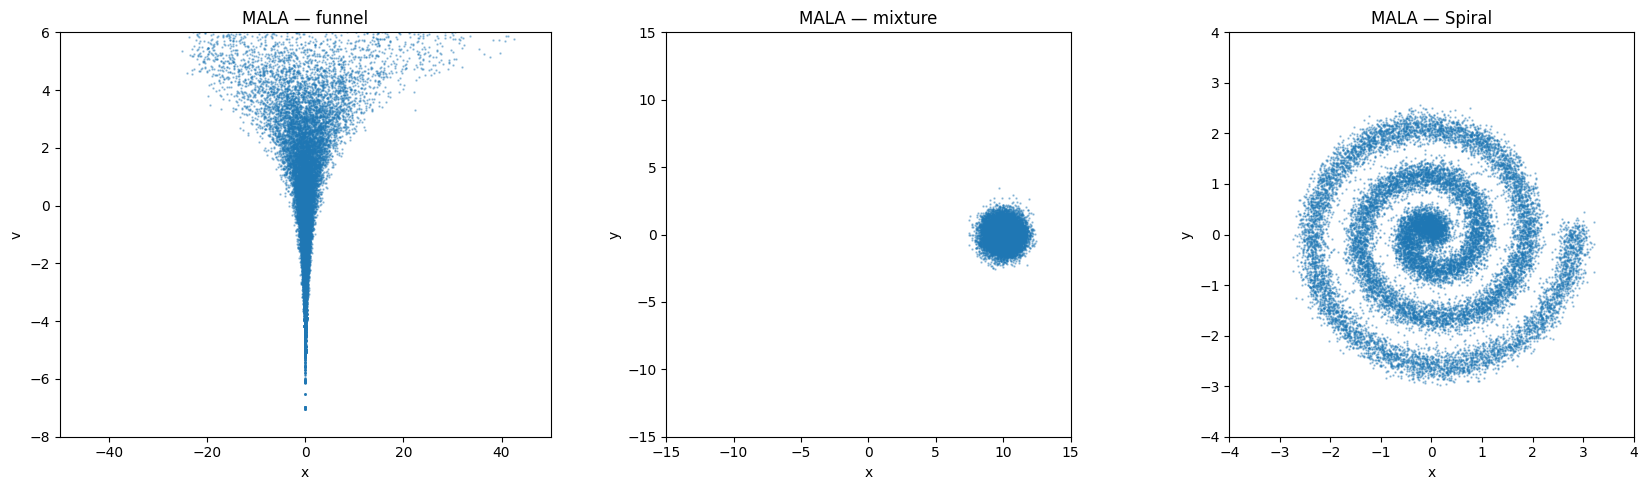

In [21]:
s_f = run_mcmc(mala(funnel_logdensity), init_funnel, key, init_params_kwargs={"step_size": 0.05})
s_m = run_mcmc(mala(mixture_logdensity), init_mixture, key, init_params_kwargs={"step_size": 0.05})
s_s = run_mcmc(mala(spiral_logdensity), init_spiral, key, init_params_kwargs={"step_size": 0.05})
plot_triplet("MALA", s_f, s_m, s_s)

## RW-MH

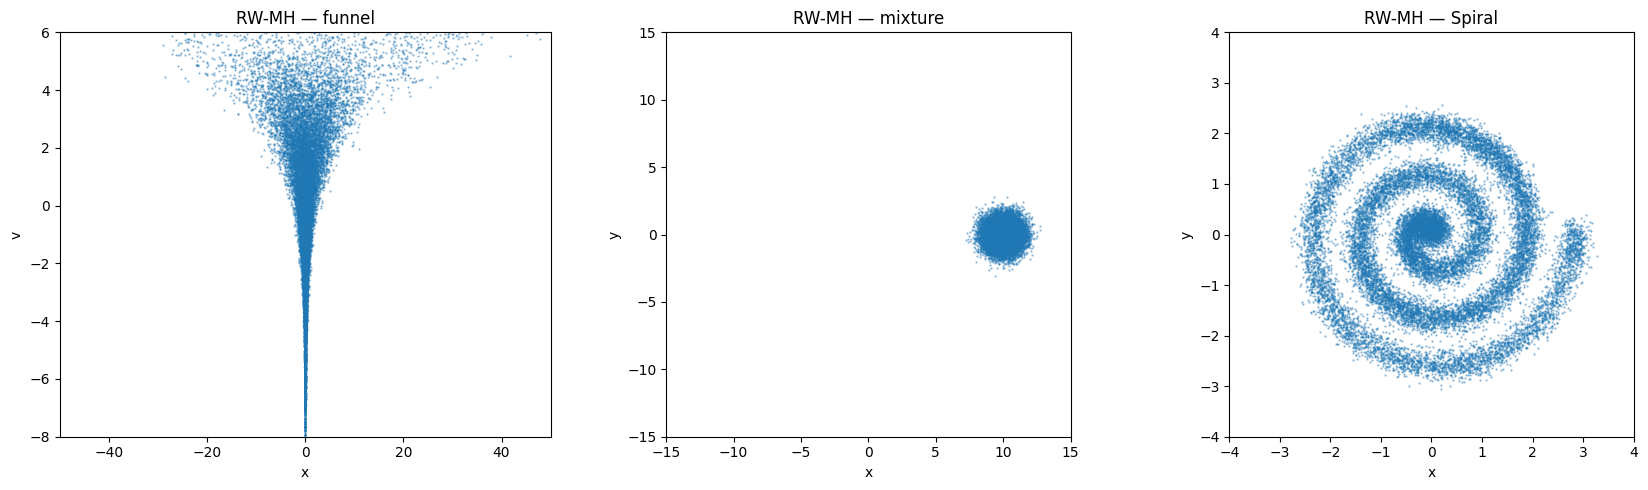

In [22]:
s_f = run_mcmc(gauss_rwmh(funnel_logdensity), init_funnel, key, init_params_kwargs={"step_size": 0.5})
s_m = run_mcmc(gauss_rwmh(mixture_logdensity), init_mixture, key, init_params_kwargs={"step_size": 0.5})
s_s = run_mcmc(gauss_rwmh(spiral_logdensity), init_spiral, key, init_params_kwargs={"step_size": 0.1})
plot_triplet("RW-MH", s_f, s_m, s_s)

## IMH

In [23]:
s_f = run_mcmc(gaussian_imh(funnel_logdensity), init_funnel, key, num_samples=2_000, thin=10, init_params_kwargs={"cov": 50.0 * jnp.ones(2)})
s_m = run_mcmc(gaussian_imh(mixture_logdensity), init_mixture, key, num_samples=2_000, thin=10, init_params_kwargs={"cov": 50.0 * jnp.ones(2)})
s_s = run_mcmc(gaussian_imh(spiral_logdensity), init_spiral, key, num_samples=2_000, thin=10, init_params_kwargs={"cov": 50.0 * jnp.ones(2)})
plot_triplet("IMH", s_f, s_m, s_s)

TypeError: Error interpreting argument to <function MCMC.sample_kernel at 0x1188c6c00> as an abstract array. The problematic value is of type <class 'jax._src.util.HashablePartial'> and was passed to the function at path params.unflatten.
This typically means that a jit-wrapped function was called with a non-array argument, and this argument was not marked as static using the static_argnums or static_argnames parameters of jax.jit.

KeyboardInterrupt: 

## Elliptical Slice Sampling

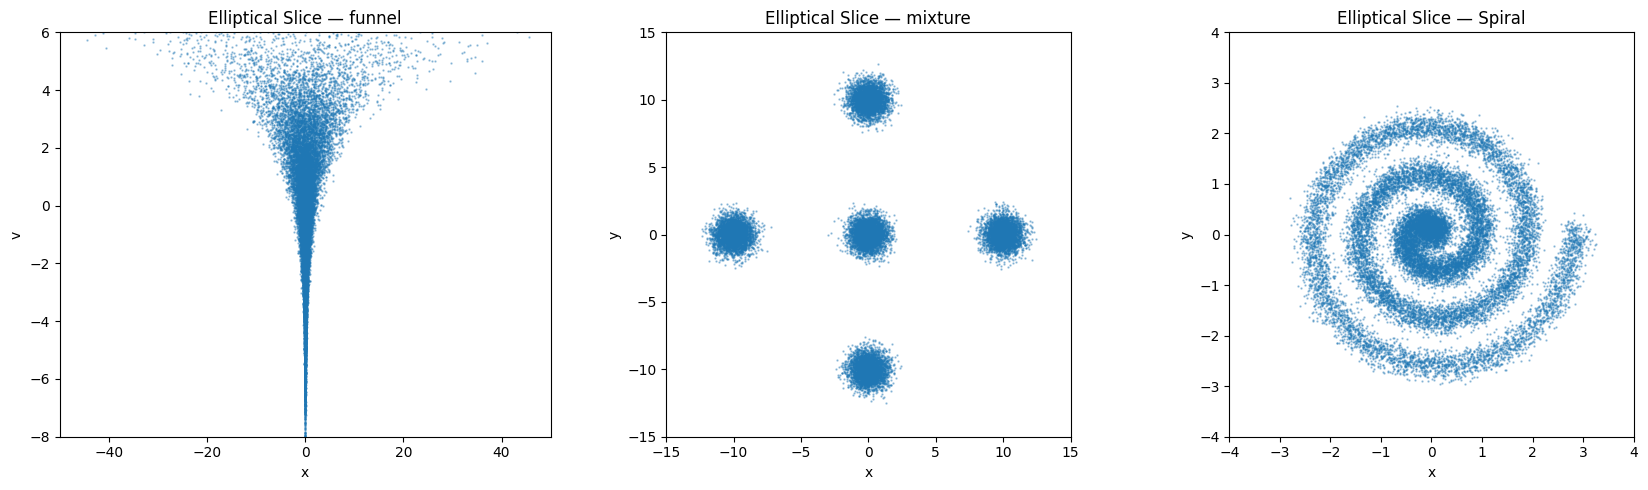

In [ ]:
s_f = run_mcmc(elliptical_slice(funnel_logdensity, cov_matrix=50.0 * jnp.ones(2), mean=jnp.zeros(2)), init_funnel, key, thin=10)
s_m = run_mcmc(elliptical_slice(mixture_logdensity, cov_matrix=50.0 * jnp.ones(2), mean=jnp.zeros(2)), init_mixture, key, thin=10)
s_s = run_mcmc(elliptical_slice(spiral_logdensity, cov_matrix=50.0 * jnp.ones(2), mean=jnp.zeros(2)), init_spiral, key, thin=10)
plot_triplet("Elliptical Slice", s_f, s_m, s_s)

## Slice Sampling

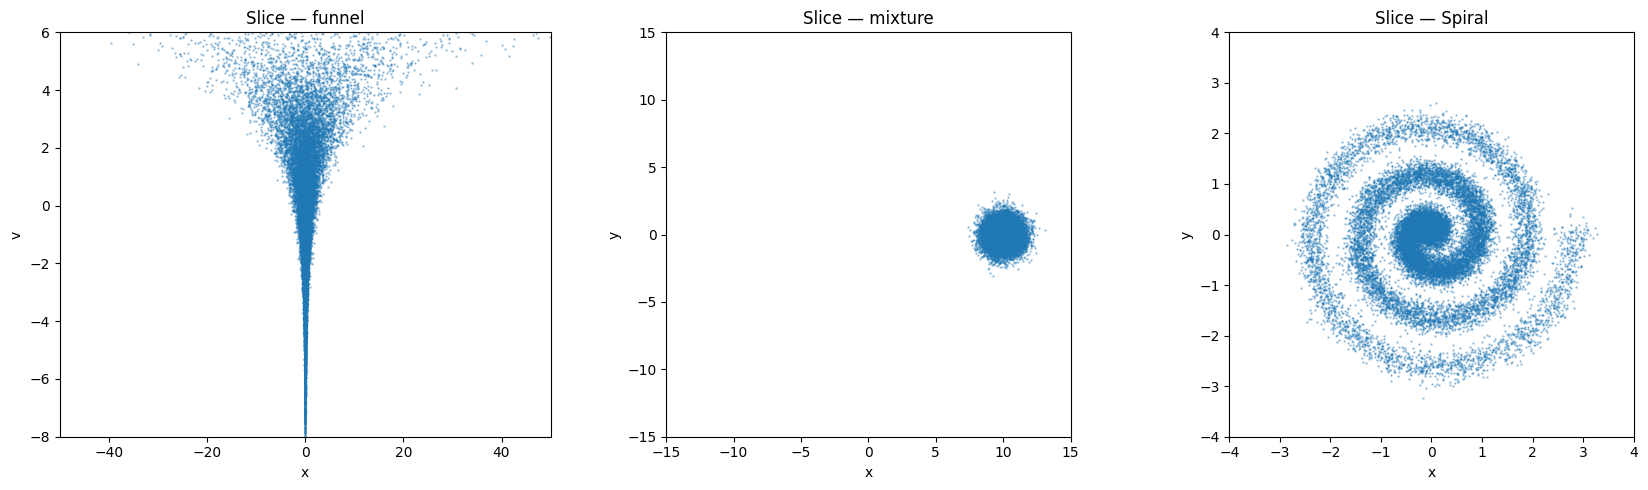

In [ ]:
s_f = run_mcmc(slice(funnel_logdensity), init_funnel, key, init_params_kwargs={"step_size": 1.0})
s_m = run_mcmc(slice(mixture_logdensity), init_mixture, key, init_params_kwargs={"step_size": 1.0})
s_s = run_mcmc(slice(spiral_logdensity), init_spiral, key, init_params_kwargs={"step_size": 0.1})
plot_triplet("Slice", s_f, s_m, s_s)

## Latent Slice Sampling

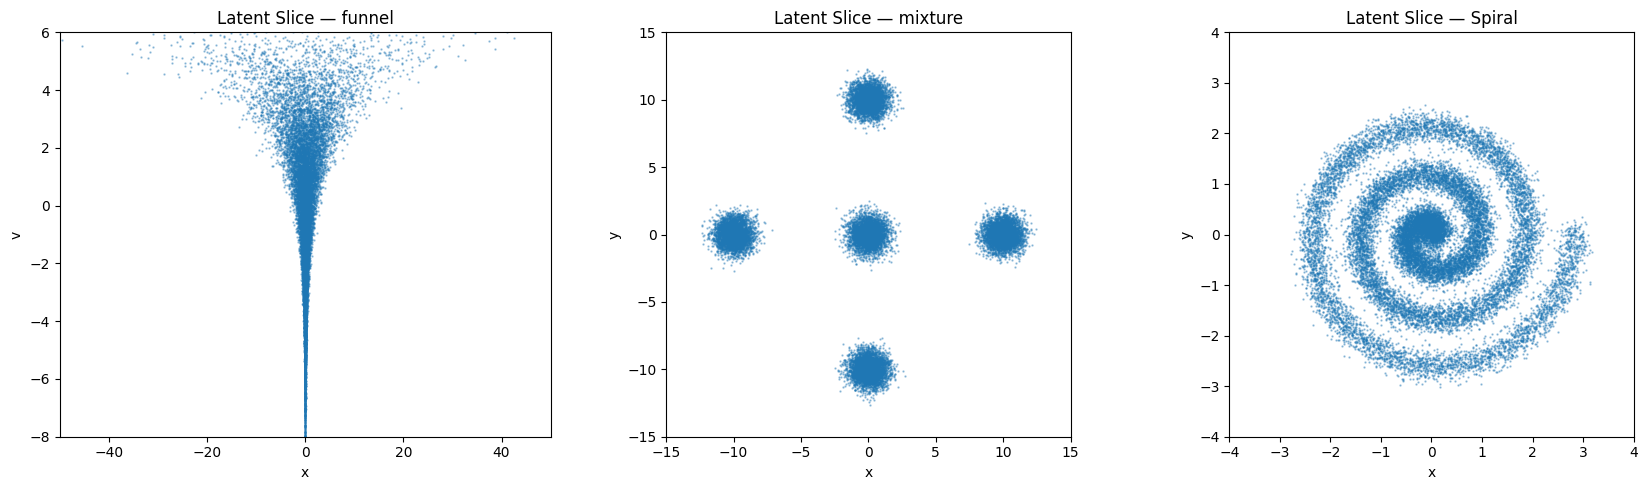

In [ ]:
s_f = run_mcmc(latent_slice(funnel_logdensity), init_funnel, key, init_params_kwargs={"step_size": 0.1})
s_m = run_mcmc(latent_slice(mixture_logdensity), init_mixture, key, init_params_kwargs={"step_size": 0.1})
s_s = run_mcmc(latent_slice(spiral_logdensity), init_spiral, key, init_params_kwargs={"step_size": 0.1})
plot_triplet("Latent Slice", s_f, s_m, s_s)

## MCLMC

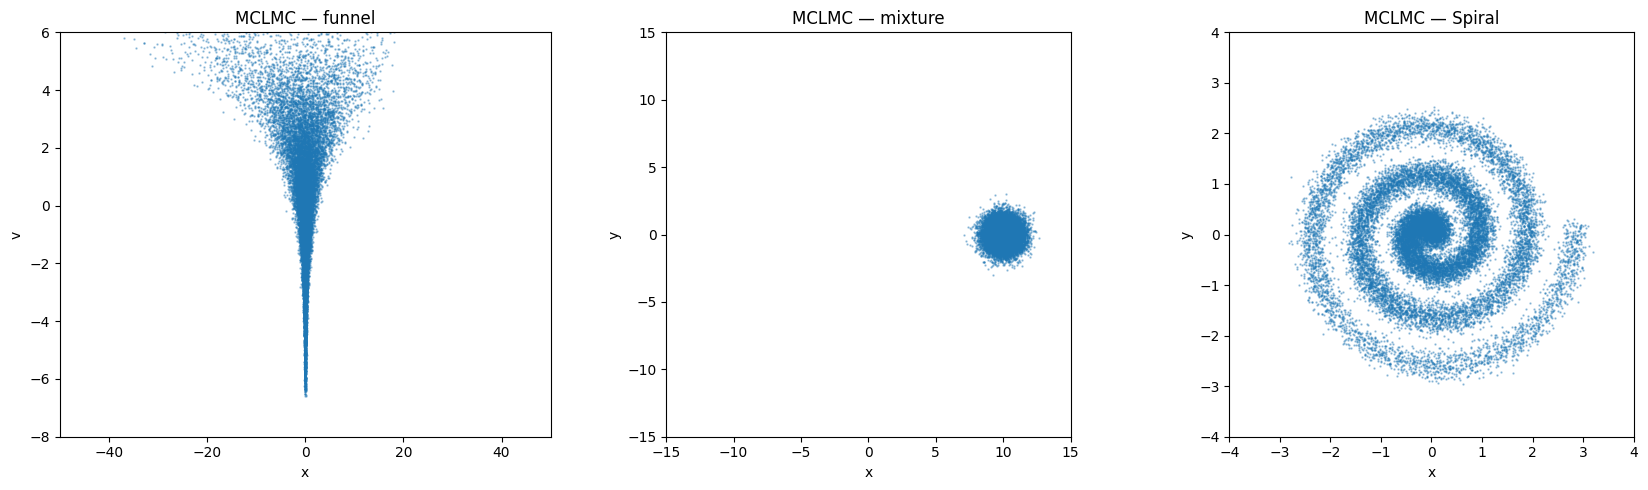

In [ ]:
s_f = run_mcmc(mclmc(funnel_logdensity), init_funnel, key, init_params_kwargs={"step_size": 0.1, "L": 1.0})
s_m = run_mcmc(mclmc(mixture_logdensity), init_mixture, key, init_params_kwargs={"step_size": 0.1, "L": 1.0})
s_s = run_mcmc(mclmc(spiral_logdensity), init_spiral, key, init_params_kwargs={"step_size": 0.05, "L": 1.0})
plot_triplet("MCLMC", s_f, s_m, s_s)

## Adjusted MCLMC

In [ ]:
s_f = run_mcmc(adjusted_mclmc(funnel_logdensity), init_funnel, key, init_params_kwargs={"step_size": 0.05, "num_integration_steps": 50})
s_m = run_mcmc(adjusted_mclmc(mixture_logdensity), init_mixture, key, init_params_kwargs={"step_size": 0.05, "num_integration_steps": 50})
s_s = run_mcmc(adjusted_mclmc(spiral_logdensity), init_spiral, key, init_params_kwargs={"step_size": 0.005, "num_integration_steps": 50})
plot_triplet("Adj. MCLMC", s_f, s_m, s_s)

## Adjusted MCLMC (Dynamic)

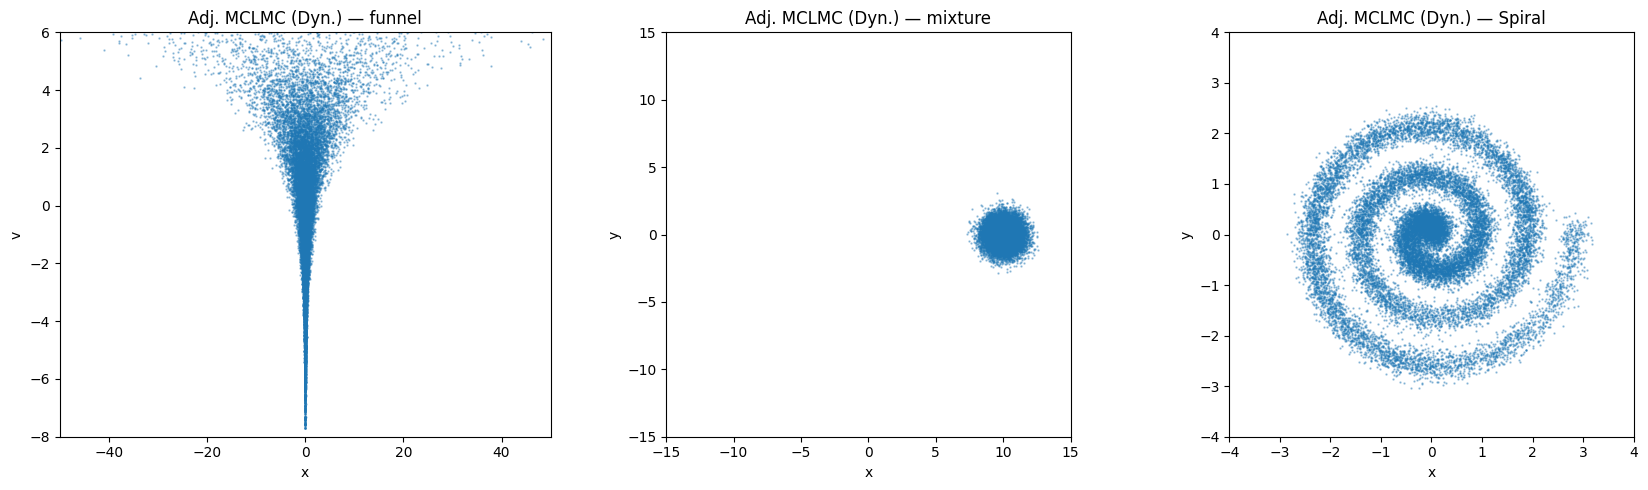

In [ ]:
s_f = run_mcmc(adjusted_mclmc_dynamic(funnel_logdensity, average_integration_steps=30), init_funnel, key, init_params_kwargs={"step_size": 0.05})
s_m = run_mcmc(adjusted_mclmc_dynamic(mixture_logdensity, average_integration_steps=30), init_mixture, key, init_params_kwargs={"step_size": 0.05})
s_s = run_mcmc(adjusted_mclmc_dynamic(spiral_logdensity, average_integration_steps=30), init_spiral, key, init_params_kwargs={"step_size": 0.005})
plot_triplet("Adj. MCLMC (Dyn.)", s_f, s_m, s_s)

## Kernel parameter adaptation

Adaptors are separate from kernels. Local rules can be composed and run by
`MCMC.adapt`; scheduled policies such as window adaptation run through
`MCMC.warmup`.

In [ ]:
def run_mcmc_adapted(
    kernel, init_z, key, adaptor, num_adapt=500, num_samples=20_000, thin=10
):
    """Adapt kernel parameters with a local adaptor, then sample."""
    key_init, key_adapt, key_sample = jax.random.split(key, 3)
    state = kernel.init(key_init, init_z)
    init_p = kernel.init_params(state)
    runner = MCMC(kernel)
    warmup = runner.adapt(
        key_adapt, adaptor, state, init_p, num_steps=num_adapt
    )
    result = runner.sample(
        key_sample, warmup.state, num_samples, params=warmup.params, thin=thin
    )
    return result.samples, result.state, warmup.params


def run_mcmc_warmup(
    kernel, init_z, key, warmup_policy, num_adapt=500, num_samples=20_000, thin=10
):
    """Run a scheduled warmup policy, then sample."""
    key_init, key_warmup, key_sample = jax.random.split(key, 3)
    state = kernel.init(key_init, init_z)
    params = kernel.init_params(state)
    runner = MCMC(kernel)
    warmup = runner.warmup(
        key_warmup, warmup_policy, state, params, num_steps=num_adapt
    )
    result = runner.sample(
        key_sample, warmup.state, num_samples, params=warmup.params, thin=thin
    )
    return result.samples, result.state, warmup.params

### HMC with window warmup

`window_warmup` follows BlackJAX's Stan-style schedule: it tunes both
`step_size` and `inverse_mass_matrix` during a finite initialization phase.

In [ ]:
kernel_hmc = hmc(funnel_logdensity, num_integration_steps=50)
s_f, st_f, p_f = run_mcmc_warmup(
    kernel_hmc, init_funnel, key, window_warmup()
)
print(f"Funnel — step_size: {p_f.step_size:.4f}, mass: {p_f.inverse_mass_matrix}")

kernel_hmc = hmc(mixture_logdensity, num_integration_steps=50)
s_m, st_m, p_m = run_mcmc_warmup(
    kernel_hmc, init_mixture, key, window_warmup()
)
print(f"Mixture — step_size: {p_m.step_size:.4f}, mass: {p_m.inverse_mass_matrix}")

kernel_hmc = hmc(spiral_logdensity, num_integration_steps=50)
s_s, st_s, p_s = run_mcmc_warmup(
    kernel_hmc, init_spiral, key, window_warmup()
)
print(f"Spiral — step_size: {p_s.step_size:.4f}, mass: {p_s.inverse_mass_matrix}")

In [26]:
mcmc = MCMC(kernel_hmc, verbose=True)
_ = mcmc.run(jax.random.key(0), st_s, 1000000, params=p_s)

Progress: |██████████████████████████████████████████████████| 100.00% logdensity: -2.34 acceptance_rate: 0.87

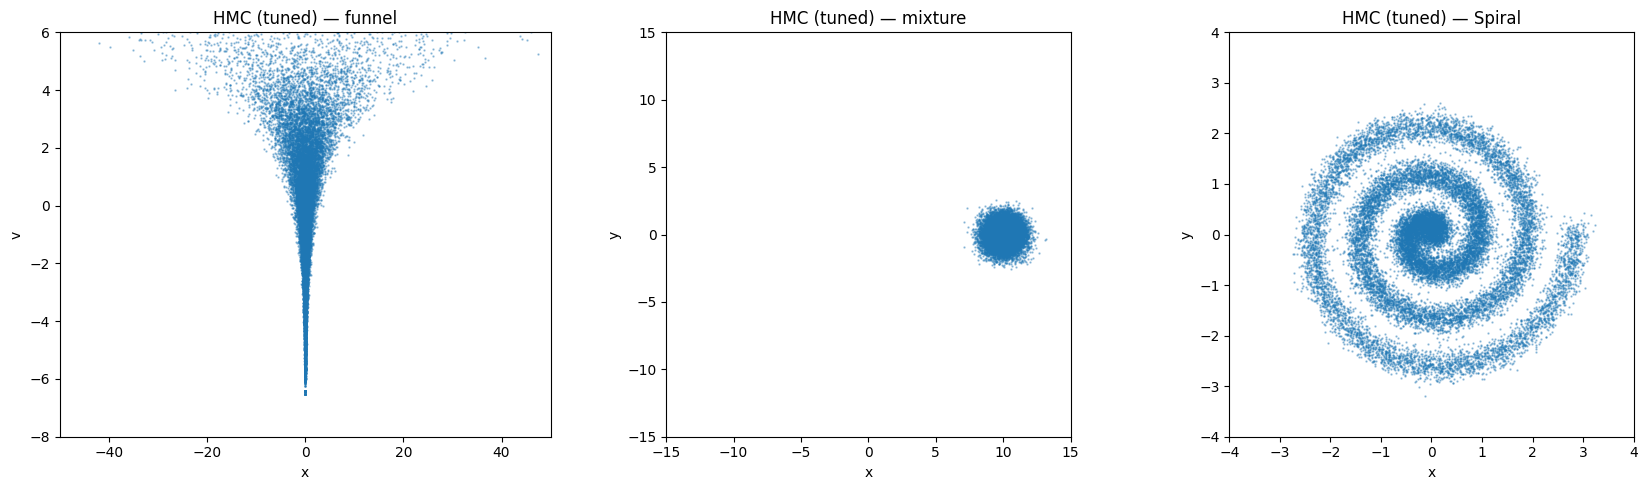

In [27]:
plot_triplet("HMC (tuned)", s_f, s_m, s_s)

### MALA with step-size adaptation

MALA adaptation tunes `step_size` toward the adaptor's target acceptance
rate (default 0.8). Compare against the hand-tuned MALA above.

In [ ]:
kernel_mala = mala(funnel_logdensity)
s_f, st_f, p_f = run_mcmc_adapted(
    kernel_mala, init_funnel, key, step_size_adaptor()
)
print(f"Funnel — step_size: {p_f.step_size:.4f}")

kernel_mala = mala(mixture_logdensity)
s_m, st_m, p_m = run_mcmc_adapted(
    kernel_mala, init_mixture, key, step_size_adaptor()
)
print(f"Mixture — step_size: {p_m.step_size:.4f}")

kernel_mala = mala(spiral_logdensity)
s_s, st_s, p_s = run_mcmc_adapted(
    kernel_mala, init_spiral, key, step_size_adaptor()
)
print(f"Spiral — step_size: {p_s.step_size:.4f}")

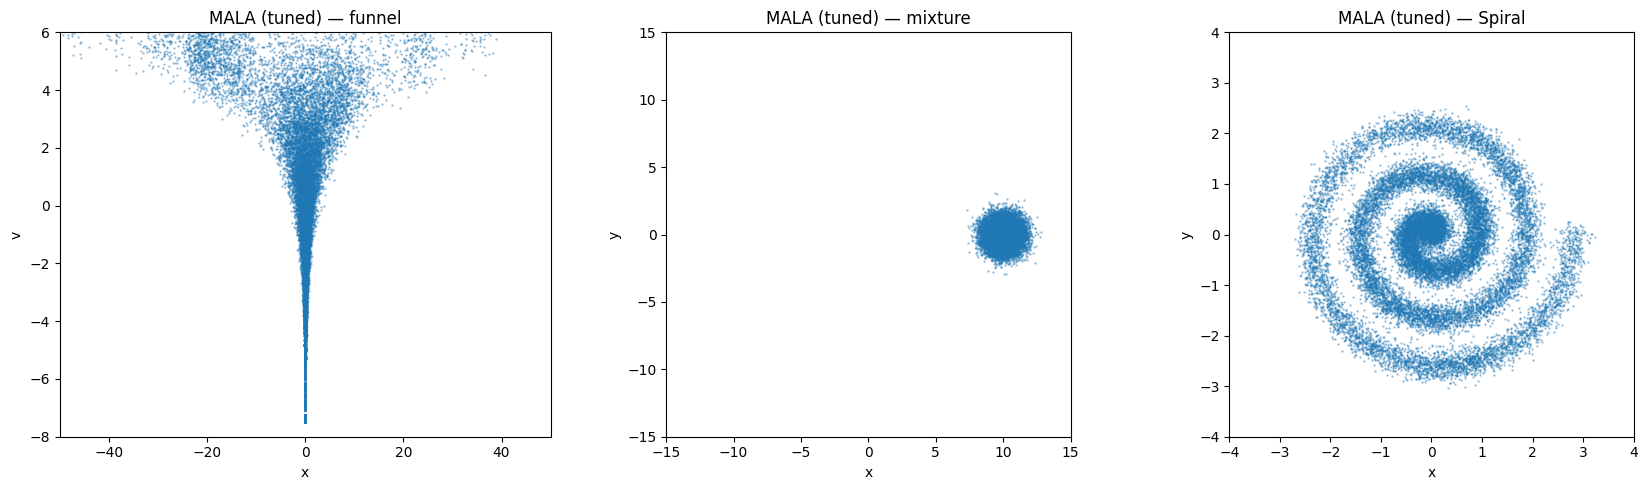

In [29]:

plot_triplet("MALA (tuned)", s_f, s_m, s_s)

### NUTS with window warmup

NUTS uses the same joint step-size and mass-matrix warmup as HMC.

In [ ]:
kernel_nuts = nuts(funnel_logdensity, max_num_doublings=10)
s_f, st_f, p_f = run_mcmc_warmup(
    kernel_nuts, init_funnel, key, window_warmup()
)
print(f"Funnel — step_size: {p_f.step_size:.4f}, mass: {p_f.inverse_mass_matrix}")

kernel_nuts = nuts(mixture_logdensity, max_num_doublings=10)
s_m, st_m, p_m = run_mcmc_warmup(
    kernel_nuts, init_mixture, key, window_warmup()
)
print(f"Mixture — step_size: {p_m.step_size:.4f}, mass: {p_m.inverse_mass_matrix}")

kernel_nuts = nuts(spiral_logdensity, max_num_doublings=10)
s_s, st_s, p_s = run_mcmc_warmup(
    kernel_nuts, init_spiral, key, window_warmup()
)
print(f"Spiral — step_size: {p_s.step_size:.4f}, mass: {p_s.inverse_mass_matrix}")

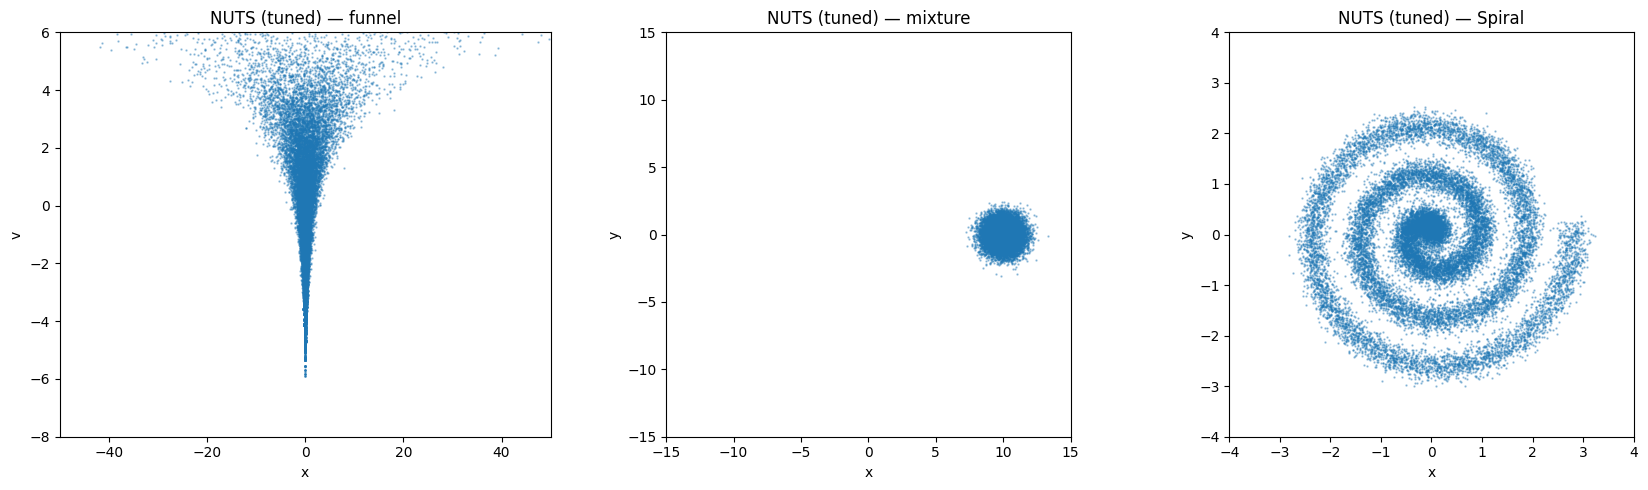

In [31]:
plot_triplet("NUTS (tuned)", s_f, s_m, s_s)

### Gaussian RW-MH with composed adaptation

The random-walk proposal needs both an overall `step_size` and per-dimension
proposal scales. `compose_adaptors` updates the acceptance-driven step size
while estimating the marginal scale from visited positions.

In [ ]:
rw_adaptor = compose_adaptors(
    step_size=step_size_adaptor(target=0.234),
    scale=covariance_adaptor(field="scale", output="standard_deviation"),
)

kernel_rw = gauss_rwmh(funnel_logdensity)
s_f, st_f, p_f = run_mcmc_adapted(kernel_rw, init_funnel, key, rw_adaptor)
print(f"Funnel — step_size: {p_f.step_size:.4f}, scale: {p_f.scale}")

kernel_rw = gauss_rwmh(mixture_logdensity)
s_m, st_m, p_m = run_mcmc_adapted(kernel_rw, init_mixture, key, rw_adaptor)
print(f"Mixture — step_size: {p_m.step_size:.4f}, scale: {p_m.scale}")

kernel_rw = gauss_rwmh(spiral_logdensity)
s_s, st_s, p_s = run_mcmc_adapted(kernel_rw, init_spiral, key, rw_adaptor)
print(f"Spiral — step_size: {p_s.step_size:.4f}, scale: {p_s.scale}")

In [ ]:
plot_triplet("RW-MH (adapted)", s_f, s_m, s_s)

### Slice sampling with width adaptation

Slice samplers do not expose an acceptance probability. Their specialized
adaptor instead tunes `step_size` using the number of density evaluations.
The same adaptor also works with `latent_slice`, whose info has the same
`num_evals` field.

In [ ]:
slice_adaptor = slice_step_size_adaptor(
    target_num_evaluations=5, max_evaluations=100
)

kernel_slice = slice(funnel_logdensity, max_evals=100)
s_f, st_f, p_f = run_mcmc_adapted(
    kernel_slice, init_funnel, key, slice_adaptor
)
print(f"Funnel — width: {p_f.step_size:.4f}")

kernel_slice = slice(mixture_logdensity, max_evals=100)
s_m, st_m, p_m = run_mcmc_adapted(
    kernel_slice, init_mixture, key, slice_adaptor
)
print(f"Mixture — width: {p_m.step_size:.4f}")

kernel_slice = slice(spiral_logdensity, max_evals=100)
s_s, st_s, p_s = run_mcmc_adapted(
    kernel_slice, init_spiral, key, slice_adaptor
)
print(f"Spiral — width: {p_s.step_size:.4f}")

In [ ]:
plot_triplet("Slice (adapted)", s_f, s_m, s_s)

### Adaptor coverage

- HMC, NUTS, and dynamic HMC: `window_warmup` for step size and mass matrix.
- MALA and acceptance-based proposals: `step_size_adaptor`.
- Gaussian RW-MH: compose `step_size_adaptor` and `covariance_adaptor`.
- Slice and latent slice: `slice_step_size_adaptor`.
- MCLMC variants: the scheduled `mclmc_warmup` policy.
- Elliptical slice and arbitrary independent proposals have no generic local adaptor; their proposal geometry must be supplied by the model or a proposal-specific warmup.

## Observations

**Funnel (varying curvature):** HMC/NUTS explore the full funnel. MALA mixes slowly on the narrow neck. RW-MH is very slow. Slice-based methods (IMH, ESS, Slice) depend on proposal/direction quality.

**Mixture (disconnected modes):** Local methods get trapped in a single mode. IMH, ESS, and Slice can occasionally hop between modes with a wide proposal, but acceptance is low.

**Spiral (thin curved ridge):** Gradient methods (HMC, NUTS, MALA) handle the ridge geometry well with small step sizes. RW-MH struggles to follow the curve. Slice sampling can adapt along the ridge if directions are chosen well.

**Adaptation:** local adaptors such as `step_size_adaptor` can be reused with `MCMC.adapt_step` between transitions or scanned by `MCMC.adapt` during warmup. Scheduled policies such as `window_warmup` use `MCMC.warmup`.